# PubMatrix — WNT signalling × obesity genes

Mirrors the worked example from the PubMatrixR vignette.

List A (WNT genes): WNT1, WNT2, WNT3A, WNT5A, WNT7B, CTNNB1, DVL1  
List B (obesity genes): LEPR, ADIPOQ, PPARG, TNF, IL6, ADRB2, INSR

Reference: Becker et al. (2003) BMC Bioinformatics 4:61.

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import pandas as pd

from pubmatrix import pubmatrix, plot_pubmatrix_heatmap

## Define gene lists

In [2]:
wnt_genes = ["WNT1", "WNT2", "WNT3A", "WNT5A", "WNT7B", "CTNNB1", "DVL1"]
obesity_genes = ["LEPR", "ADIPOQ", "PPARG", "TNF", "IL6", "ADRB2", "INSR"]

## Run PubMatrix query

This makes 7 × 7 = 49 queries to PubMed. Set `api_key` if you have one.

In [3]:
result = pubmatrix(
    A=wnt_genes,
    B=obesity_genes,
    database="pubmed",
    # api_key="YOUR_KEY_HERE",
)
result

Querying NCBI: 100%|████████████████████████████| 49/49 [00:19<00:00,  2.49query/s]


,WNT1,WNT2,WNT3A,WNT5A,WNT7B,CTNNB1,DVL1
LEPR,6,0,0,2,0,4,0
ADIPOQ,2,0,0,6,0,9,0
PPARG,2,3,7,5,1,26,0
TNF,83,4,110,123,6,216,3
IL6,75,7,86,143,9,150,3
ADRB2,1,0,0,1,0,0,0
INSR,1,1,1,1,0,4,0


## Publication counts per gene (bar plot)

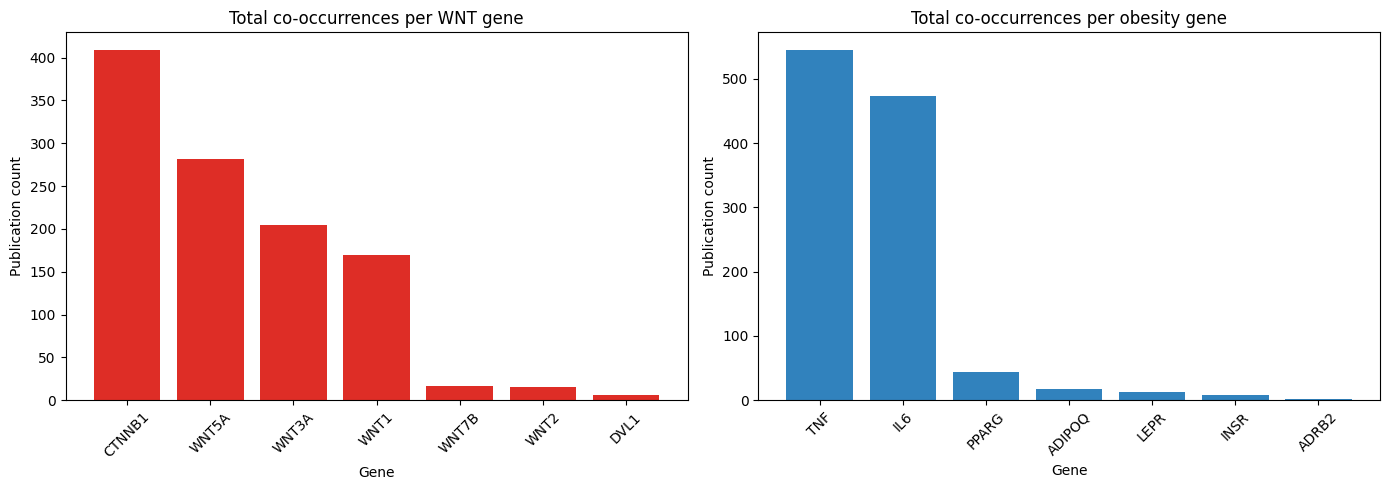

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total publications per WNT gene (column sums)
col_totals = result.sum(axis=0).sort_values(ascending=False)
axes[0].bar(col_totals.index, col_totals.values, color="#de2d26")
axes[0].set_title("Total co-occurrences per WNT gene")
axes[0].set_xlabel("Gene")
axes[0].set_ylabel("Publication count")
axes[0].tick_params(axis="x", rotation=45)

# Total publications per obesity gene (row sums)
row_totals = result.sum(axis=1).sort_values(ascending=False)
axes[1].bar(row_totals.index, row_totals.values, color="#3182bd")
axes[1].set_title("Total co-occurrences per obesity gene")
axes[1].set_xlabel("Gene")
axes[1].set_ylabel("Publication count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Heatmap with clustering

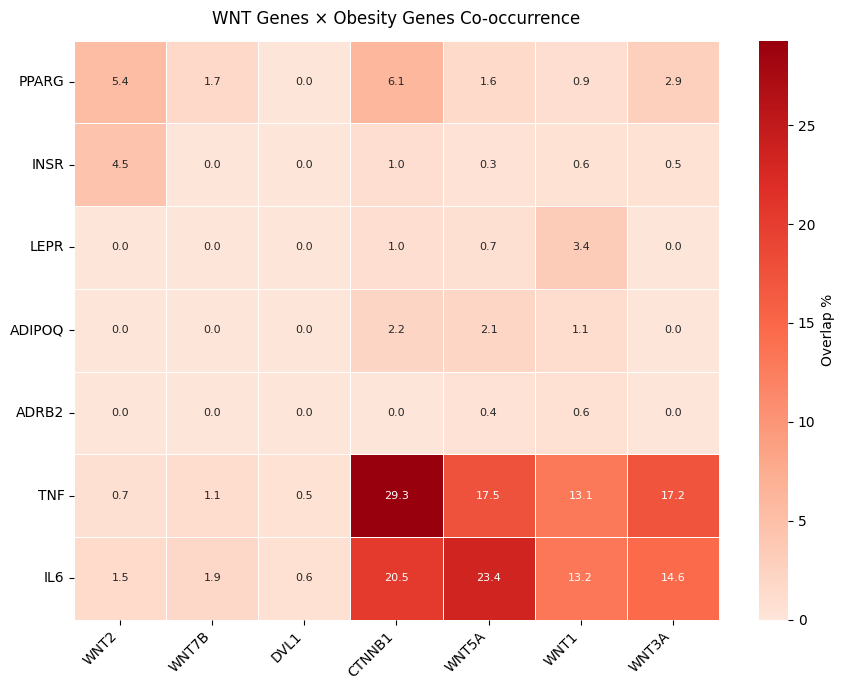

<Axes: title={'center': 'WNT Genes × Obesity Genes Co-occurrence'}>

In [5]:
plot_pubmatrix_heatmap(
    result,
    title="WNT Genes × Obesity Genes Co-occurrence",
    cluster_rows=True,
    cluster_cols=True,
    show_numbers=True,
    width=9,
    height=7,
)

## Export results

In [6]:
# Save raw counts
result.to_csv("wnt_obesity_matrix.csv")
print("Saved wnt_obesity_matrix.csv")

Saved wnt_obesity_matrix.csv
